In [1]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "alibi-detect",
#     "ipywidgets",
#     "matplotlib",
#     "numpy",
#     "pandas",
#     "polars",
#     "pyarrow",
#     "seaborn",
# ]
#
# [tool.uv]
# exclude-newer = "2025-09-18T15:51:48.126835524+02:00"
# ///

# Playing with `alibi-detect` to detect feature drift in our downsampled dataset

In [2]:
from pathlib import Path
from pprint import pprint

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from alibi_detect.cd import KSDrift

None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


## Load and prepare data

In [3]:
data_path = Path('../data/samples/v1.1/mawiflow_samples_n1000_seed42_taxonomy_balanced.parquet')
data = pl.scan_parquet(data_path)
data.head().collect()

Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,…,Fwd TCP Retrans. Count,Bwd TCP Retrans. Count,Total TCP Retrans. Count,Total Connection Flow Time,protocol_name,Label,rule_id,anomaly_id,distance_normal,distance_anomalous,heuristic,hough_sensitive,hough_optimal,hough_conservative,gamma_sensitive,gamma_optimal,gamma_conservative,kl_sensitive,kl_optimal,kl_conservative,pca_sensitive,pca_optimal,pca_conservative,taxonomy,distance,num_detectors,feature_count,duration,annotation_rank,taxonomy_orig,taxonomy_norm,month,n,seed,year,row_pct,split
str,str,i64,str,i64,i64,datetime[μs],i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,…,i64,i64,i64,i64,str,str,u32,u16,f64,f64,str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,str,f64,u8,i32,u32,i64,str,str,str,i64,i64,i64,f64,str
"""164.89.55.232-60.157.151.105-8…","""164.89.55.232""",80,"""60.157.151.105""",3588,6,2007-01-01 05:00:00.927812,119919898,43,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.358573,2.8552e6,9.9435e6,6.3997993e7,6.0,1.19919898e8,2.8552e6,9.9435e6,6.3997993e7,6.0,0.0,0.0,0.0,0.0,0.0,0,…,12,0,12,119919898,"""tcp""","""anomalous""",4,3,1.69592,1.34918,"""503""",true,false,false,true,true,true,false,false,false,true,true,false,"""ptmpHTTP""",0.34674,6,2,null,1,"""ptmpHTTP""","""HTTP""","""01""",1000,42,2007,0.001,"""train"""
"""164.89.55.232-60.4.212.91-80-1…","""164.89.55.232""",80,"""60.4.212.91""",1167,6,2007-01-01 05:00:00.936677,12557662,11,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.875959,1255766.2,2.7289e6,7.852728e6,5.0,1.2557662e7,1255766.2,2.7289e6,7.852728e6,5.0,0.0,0.0,0.0,0.0,0.0,1,…,0,0,0,12557662,"""tcp""","""anomalous""",4,3,1.69592,1.34918,"""503""",true,false,false,true,true,true,false,false,false,true,true,false,"""ptmpHTTP""",0.34674,6,2,null,1,"""ptmpHTTP""","""HTTP""","""01""",1000,42,2007,0.002,"""train"""
"""58.96.71.48-215.37.70.15-0-0-1""","""58.96.71.48""",0,"""215.37.70.15""",0,1,2007-01-01 05:00:00.954789,0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,…,0,0,0,0,"""icmp""","""benign""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""benign""","""benign""","""01""",1000,42,2007,0.001,"""train"""
"""59.233.149.59-164.89.55.232-37…","""59.233.149.59""",3740,"""164.89.55.232""",80,6,2007-01-01 05:00:00.974791,119915788,704,1006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.260007,70167.225278,132147.80759,1.41131e6,6.0,1.19906131e8,170563.486486,206886.664881,2.364261e6,11851.0,1.19906056e8,119309.508458,167672.695929,1.782101e6,6.0,0,…,211,101,312,119915788,"""tcp""","""anomalous""",18,12,2.04949,1.60078,"""503""",true,true,true,true,true,false,true,false,false,true,true,true,"""mptpHTTP""",0.44871,9,2,null,1,"""mptpHTTP""","""HTTP""","""01""",1000,42,2007,0.003,"""train"""
"""194.71.186.28-145.65.21.250-0-…","""194.71.186.28""",0,"""145.65.21.250""",0,1,2007-01-01 05:00:01.011757,2046837,2,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.977117,2.046837e6,0.0,2.046837e6,2.046837e6,2.046837e6,2.046837e6,0.0,2.046837e6,2.046837e6,0.0,0.0,0.0,0.0,0.0,0,…,0,0,0,0,"""icmp""","""anomalous""",36,25,2.24066,2.10735,"""020""",false,false,false,false,false,false,true,true,true,false,false,false,"""ntscICec""",0.13331,3,3,46,1,"""ntscICec""","""Network scan ICMP""","""01""",1000,42,2007,0.001,"""train"""


In [4]:
years = data.select('year').unique().sort(by='year').collect()['year'].to_list()
years

[2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024]

In [5]:
labels = data.select('taxonomy_norm').unique().sort(by='taxonomy_norm').collect()['taxonomy_norm'].to_list()
labels

['Alpha flow',
 'DoS',
 'HTTP',
 'IPv6 tunneling',
 'Multi. points',
 'Network scan ICMP',
 'Network scan TCP',
 'Network scan UDP',
 'Other',
 'Port scan',
 'Unknown',
 'benign']

In [6]:
CATEGORICAL_FEATURES = [
    "Protocol",
    "ICMP Code",
    "ICMP Type",
]
NUMERICAL_FEATURES = [
    "Flow Duration",
    "Total Fwd Packet",
    "Total Bwd packets",
    "Total Length of Fwd Packet",
    "Total Length of Bwd Packet",
    "Fwd Packet Length Max",
    "Fwd Packet Length Min",
    "Fwd Packet Length Mean",
    "Fwd Packet Length Std",
    "Bwd Packet Length Max",
    "Bwd Packet Length Min",
    "Bwd Packet Length Mean",
    "Bwd Packet Length Std",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Flow IAT Mean",
    "Flow IAT Std",
    "Flow IAT Max",
    "Flow IAT Min",
    "Fwd IAT Total",
    "Fwd IAT Mean",
    "Fwd IAT Std",
    "Fwd IAT Max",
    "Fwd IAT Min",
    "Bwd IAT Total",
    "Bwd IAT Mean",
    "Bwd IAT Std",
    "Bwd IAT Max",
    "Bwd IAT Min",
    "Fwd PSH Flags",
    "Bwd PSH Flags",
    "Fwd URG Flags",
    "Bwd URG Flags",
    "Fwd RST Flags",
    "Bwd RST Flags",
    "Fwd Header Length",
    "Bwd Header Length",
    "Fwd Packets/s",
    "Bwd Packets/s",
    "Packet Length Min",
    "Packet Length Max",
    "Packet Length Mean",
    "Packet Length Std",
    "Packet Length Variance",
    "FIN Flag Count",
    "SYN Flag Count",
    "RST Flag Count",
    "PSH Flag Count",
    "ACK Flag Count",
    "URG Flag Count",
    "CWR Flag Count",
    "ECE Flag Count",
    "Down/Up Ratio",
    "Average Packet Size",
    "Fwd Segment Size Avg",
    "Bwd Segment Size Avg",
    "Fwd Bytes/Bulk Avg",
    "Fwd Packet/Bulk Avg",
    "Fwd Bulk Rate Avg",
    "Bwd Bytes/Bulk Avg",
    "Bwd Packet/Bulk Avg",
    "Bwd Bulk Rate Avg",
    "Subflow Fwd Packets",
    "Subflow Fwd Bytes",
    "Subflow Bwd Packets",
    "Subflow Bwd Bytes",
    "FWD Init Win Bytes",
    "Bwd Init Win Bytes",
    "Fwd Act Data Pkts",
    "Bwd Act Data Pkts",
    "Fwd Seg Size Min",
    "Bwd Seg Size Min",
    "Active Mean",
    "Active Std",
    "Active Max",
    "Active Min",
    "Idle Mean",
    "Idle Std",
    "Idle Max",
    "Idle Min",
    "Fwd TCP Retrans. Count",
    "Bwd TCP Retrans. Count",
    "Total TCP Retrans. Count",
    "Total Connection Flow Time",
]

## Overall drift of numerical features with Kolmogorov-Smirnov test

In [7]:
cd = KSDrift(
    x_ref=data.filter(pl.col('year') == years[0]).select(NUMERICAL_FEATURES).collect().to_numpy(),
    p_val=0.05,
    correction='fdr',
    alternative='two-sided'
)

In [8]:
preds = {}
for year in years[1:]:
    print(f"Computing drift for year {year}...")
    preds[year] = cd.predict(
        data.filter(pl.col('year') == year).select(NUMERICAL_FEATURES).collect().to_numpy(),
        drift_type='batch',
        return_p_val=True,
        return_distance=True
    )
    print(f"\tDrift detected: {preds[year]['data']['is_drift']}")

Computing drift for year 2008...
	Drift detected: 1
Computing drift for year 2009...
	Drift detected: 1
Computing drift for year 2010...
	Drift detected: 1
Computing drift for year 2011...
	Drift detected: 1
Computing drift for year 2012...
	Drift detected: 1
Computing drift for year 2013...
	Drift detected: 1
Computing drift for year 2014...
	Drift detected: 1
Computing drift for year 2015...
	Drift detected: 1
Computing drift for year 2016...
	Drift detected: 1
Computing drift for year 2017...
	Drift detected: 1
Computing drift for year 2018...
	Drift detected: 1
Computing drift for year 2019...
	Drift detected: 1
Computing drift for year 2020...
	Drift detected: 1
Computing drift for year 2021...
	Drift detected: 1
Computing drift for year 2022...
	Drift detected: 1
Computing drift for year 2023...
	Drift detected: 1
Computing drift for year 2024...
	Drift detected: 1


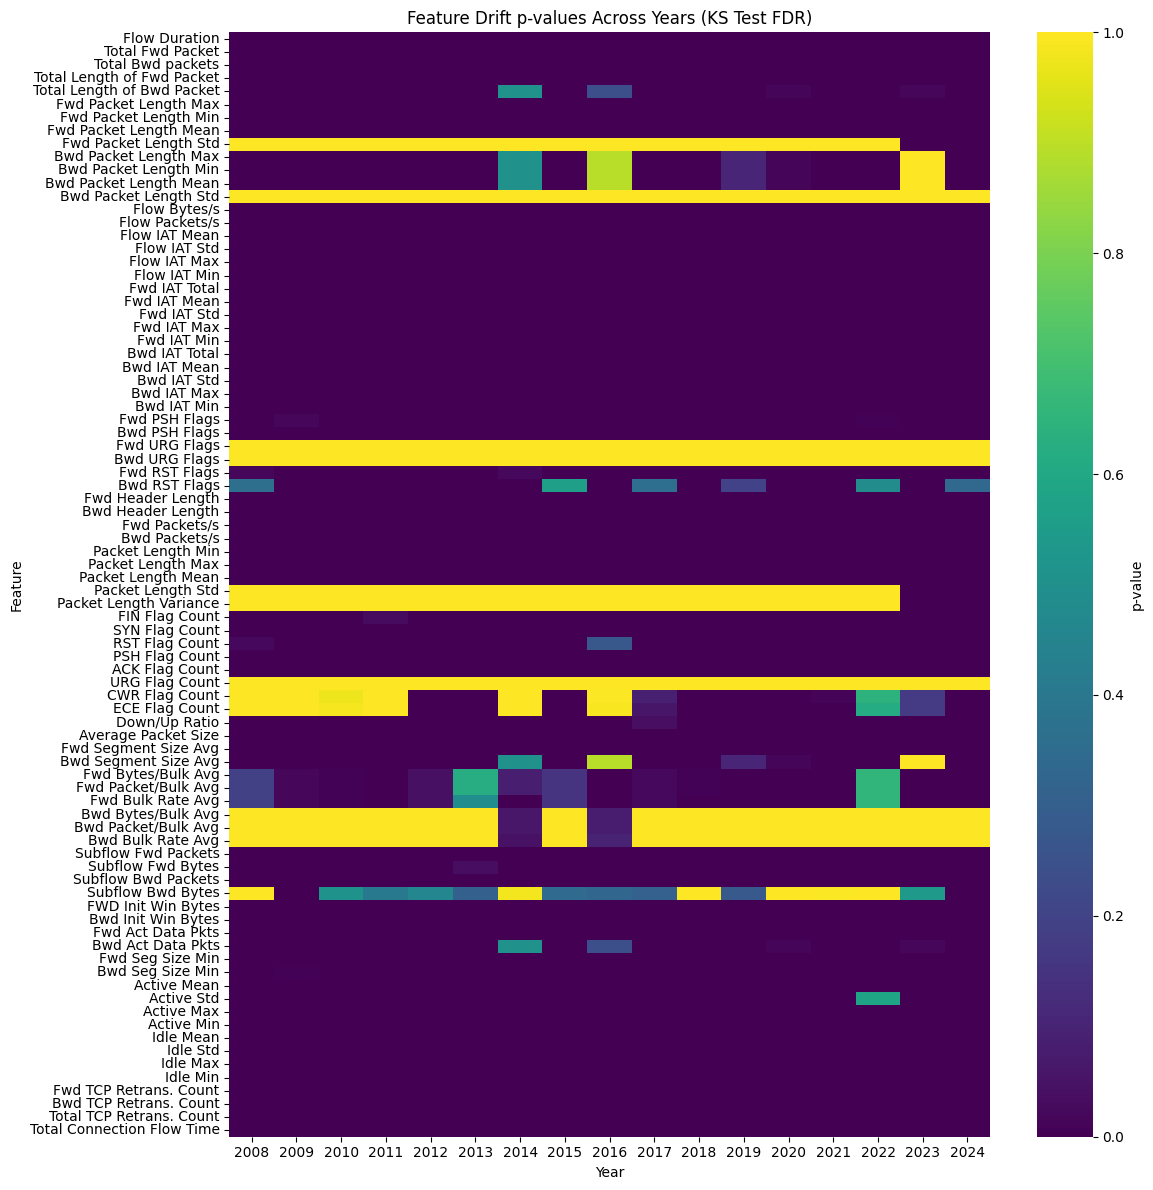

In [9]:
# Collect p-values for each feature and year
feature_names = NUMERICAL_FEATURES
years_test = years[1:]
pvals_matrix = np.array([preds[year]['data']['p_val'] for year in years_test])  # shape: (n_years, n_features)

# Plot heatmap
plt.figure(figsize=(12, 12))
sns.heatmap(
    pvals_matrix.T,
    xticklabels=years_test,
    yticklabels=feature_names,
    cmap="viridis",
    cbar_kws={'label': 'p-value'},
    vmin=0, vmax=1
)
plt.xlabel("Year")
plt.ylabel("Feature")
plt.title("Feature Drift p-values Across Years (KS Test FDR)")
plt.tight_layout()
plt.show()

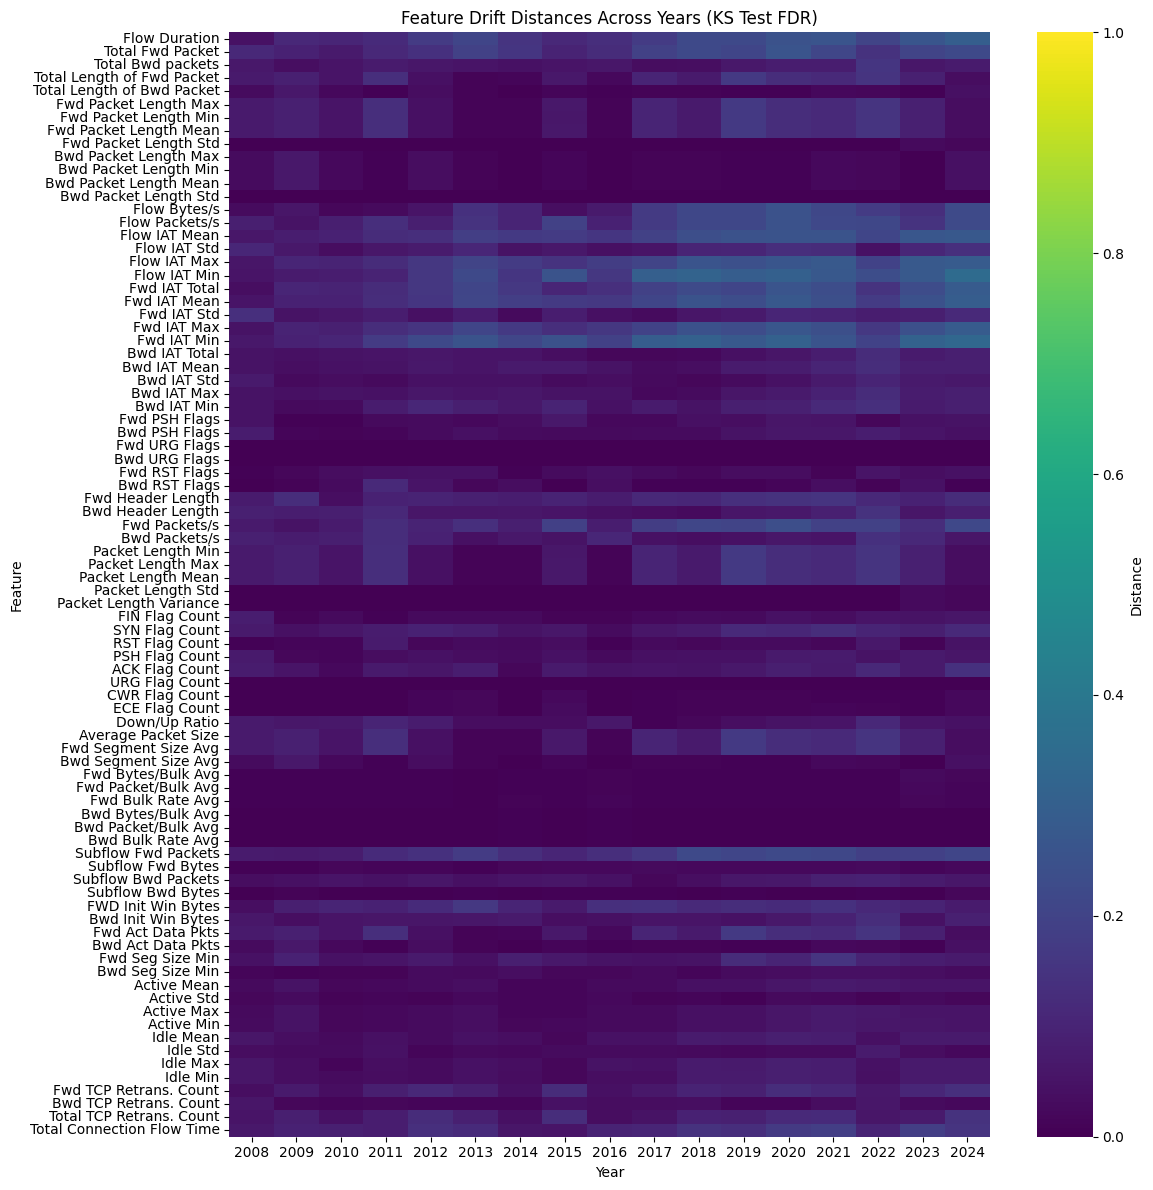

In [10]:
distance_matrix = np.array([preds[year]['data']['distance'] for year in years_test])  # shape: (n_years, n_features)
plt.figure(figsize=(12, 12))
sns.heatmap(
    distance_matrix.T,
    xticklabels=years_test,
    yticklabels=feature_names,
    cmap="viridis",
    cbar_kws={'label': 'Distance'},
    vmin=0, vmax=1
)
plt.xlabel("Year")
plt.ylabel("Feature")
plt.title("Feature Drift Distances Across Years (KS Test FDR)")
plt.tight_layout()
plt.show()